In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error
from xgboost import XGBRegressor
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("ai_job_dataset1.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(15000, 20)
['job_id', 'job_title', 'salary_usd', 'salary_currency', 'salary_local', 'experience_level', 'employment_type', 'company_location', 'company_size', 'employee_residence', 'remote_ratio', 'required_skills', 'education_required', 'years_experience', 'industry', 'posting_date', 'application_deadline', 'job_description_length', 'benefits_score', 'company_name']


,job_id,job_title,salary_usd,salary_currency,salary_local,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,Data Scientist,219728,USD,219728,EX,PT,Sweden,M,Sweden,0,"Python, Computer Vision, R, Docker",Associate,13,Transportation,2024-09-23,2024-10-31,1132,6.6,TechCorp Inc
1,AI00002,Head of AI,230237,JPY,25326070,EX,PT,Japan,L,Japan,50,"Kubernetes, MLOps, Tableau, Python",Bachelor,10,Transportation,2024-07-26,2024-09-12,2299,8.5,Cloud AI Solutions
2,AI00003,Data Engineer,128890,EUR,109557,EX,CT,Germany,S,Germany,100,"Spark, Scala, Hadoop, PyTorch, GCP",Bachelor,12,Automotive,2025-01-19,2025-03-28,1329,5.5,Quantum Computing Inc
3,AI00004,Computer Vision Engineer,96349,USD,96349,MI,FL,Finland,L,Finland,50,"MLOps, Linux, Tableau, Python",PhD,2,Automotive,2024-07-20,2024-09-06,1132,6.8,Cognitive Computing
4,AI00005,Robotics Engineer,63065,EUR,53605,EN,FT,France,S,France,100,"R, Scala, SQL, GCP, Python",Associate,0,Finance,2025-03-16,2025-05-09,2011,9.3,Advanced Robotics


In [3]:
df = df[['job_title', 'experience_level', 'employment_type',
         'company_location', 'company_size', 'employee_residence',
         'remote_ratio', 'years_experience', 'salary_usd']].dropna()

print(df.shape)
print(df['experience_level'].value_counts())
print(df['years_experience'].describe())

(15000, 9)
experience_level
EX    3843
MI    3764
SE    3741
EN    3652
Name: count, dtype: int64
count    15000.000000
mean         6.365667
std          5.598551
min          0.000000
25%          2.000000
50%          5.000000
75%         10.000000
max         19.000000
Name: years_experience, dtype: float64


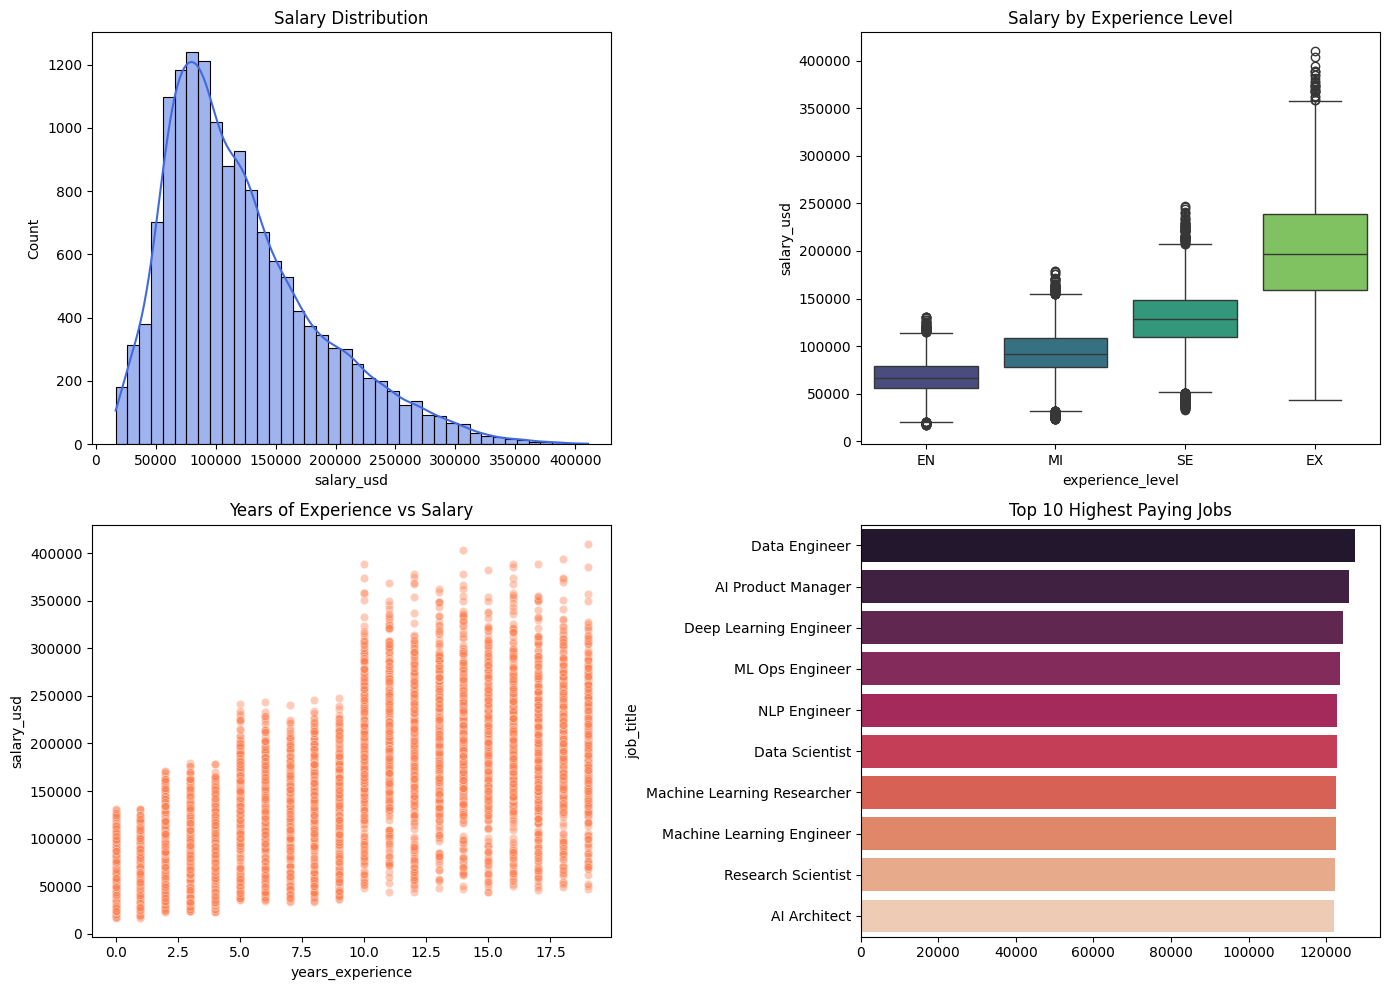

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1 - Salary Distribution
sns.histplot(df['salary_usd'], bins=40, kde=True, color='royalblue', ax=axes[0,0])
axes[0,0].set_title('Salary Distribution')

# Chart 2 - Experience Level vs Salary
exp_order = ['EN', 'MI', 'SE', 'EX']
sns.boxplot(x='experience_level', y='salary_usd', data=df, order=exp_order, palette='viridis', ax=axes[0,1])
axes[0,1].set_title('Salary by Experience Level')

# Chart 3 - Years Experience vs Salary
sns.scatterplot(x='years_experience', y='salary_usd', data=df, alpha=0.4, color='coral', ax=axes[1,0])
axes[1,0].set_title('Years of Experience vs Salary')

# Chart 4 - Top 10 Job Titles
top_jobs = df.groupby('job_title')['salary_usd'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_jobs.values, y=top_jobs.index, palette='rocket', ax=axes[1,1])
axes[1,1].set_title('Top 10 Highest Paying Jobs')

plt.tight_layout()
plt.savefig('charts.png')
plt.show()

In [5]:
# Encode categorical columns
encoders = {}
cat_cols = ['job_title', 'experience_level', 'employment_type',
            'company_location', 'company_size', 'employee_residence']

df_model = df.copy()
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    encoders[col] = le

X = df_model.drop('salary_usd', axis=1)
y = df_model['salary_usd']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)
print(f"R² Score: {r2_score(y_test, preds):.3f}")
print(f"MAE: ${mean_absolute_error(y_test, preds):,.0f}")

R² Score: 0.878
MAE: $15,782


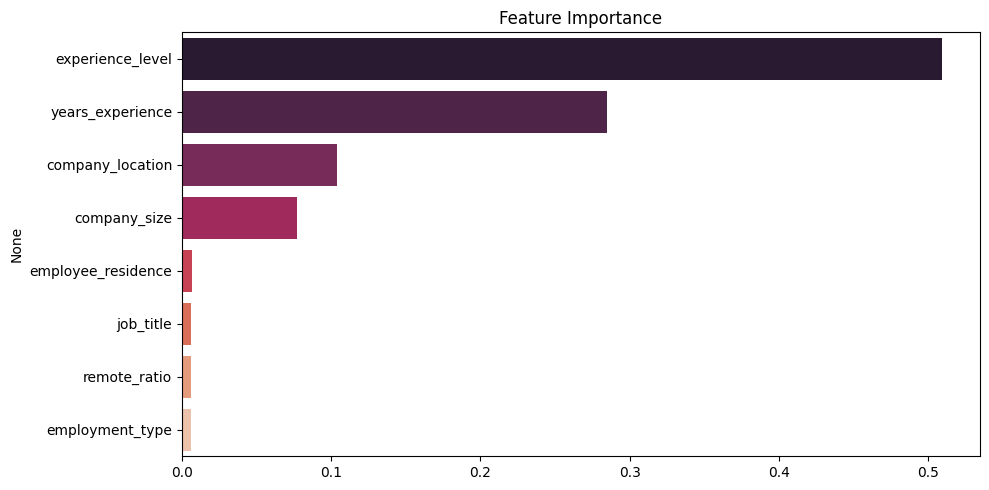

In [6]:
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=importance.values, y=importance.index, palette='rocket')
plt.title('Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

In [8]:
import joblib

joblib.dump(model, "salary_prediction_model.pkl")
joblib.dump(encoders, "model_columns.pkl")
print("✅ Saved!")

from google.colab import files
files.download("salary_prediction_model.pkl")
files.download("model_columns.pkl")

✅ Saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
import os

# Check if the dataset file exists, and if not, instruct the user to upload it.
file_path = "ai_job_dataset1.csv"
if not os.path.exists(file_path):
    print(f"Error: The file '{file_path}' was not found.")
    print("Please upload the 'ai_job_dataset1.csv' file to your Colab environment or ensure it's in the correct directory.")
    raise FileNotFoundError(f"Missing required data file: {file_path}")

# Re-define df (from cells 2rqDldknflNT and DofJdsGBfnGH)
df = pd.read_csv(file_path)
df = df[['job_title', 'experience_level', 'employment_type',
         'company_location', 'company_size', 'employee_residence',
         'remote_ratio', 'years_experience', 'salary_usd']].dropna()

# Re-define X and model (from cell 0VqL8UTuf2Hv)
encoders = {}
cat_cols = ['job_title', 'experience_level', 'employment_type',
            'company_location', 'company_size', 'employee_residence']

df_model = df.copy()
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    encoders[col] = le

X = df_model.drop('salary_usd', axis=1)
y = df_model['salary_usd']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
model.fit(X_train, y_train)

# Chart 1 - Salary Distribution
plt.figure(figsize=(10,5))
sns.histplot(df['salary_usd'], bins=40, kde=True, color='royalblue')
plt.title('Salary Distribution')
plt.tight_layout()
plt.savefig('chart1_salary_distribution.png')
plt.close()

# Chart 2 - Experience Level vs Salary
plt.figure(figsize=(10,5))
sns.boxplot(x='experience_level', y='salary_usd', data=df, order=['EN','MI','SE','EX'], palette='viridis')
plt.title('Salary by Experience Level')
plt.tight_layout()
plt.savefig('chart2_experience_salary.png')
plt.close()

# Chart 3 - Years Experience vs Salary
plt.figure(figsize=(10,5))
sns.scatterplot(x='years_experience', y='salary_usd', data=df, alpha=0.4, color='coral')
plt.title('Years of Experience vs Salary')
plt.tight_layout()
plt.savefig('chart3_years_salary.png')
plt.close()

# Chart 4 - Top 10 Jobs
plt.figure(figsize=(10,5))
top_jobs = df.groupby('job_title')['salary_usd'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_jobs.values, y=top_jobs.index, palette='rocket')
plt.title('Top 10 Highest Paying Jobs')
plt.tight_layout()
plt.savefig('chart4_top_jobs.png')
plt.close()

# Chart 5 - Feature Importance
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x=importance.values, y=importance.index, palette='rocket')
plt.title('Feature Importance')
plt.tight_layout()
plt.savefig('chart5_feature_importance.png')
plt.close()

print("✅ All charts saved!")

# Download all
files.download("chart1_salary_distribution.png")
files.download("chart2_experience_salary.png")
files.download("chart3_years_salary.png")
files.download("chart4_top_jobs.png")
files.download("chart5_feature_importance.png")

/tmp/ipykernel_3822/1609929718.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='experience_level', y='salary_usd', data=df, order=['EN','MI','SE','EX'], palette='viridis')
/tmp/ipykernel_3822/1609929718.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_jobs.values, y=top_jobs.index, palette='rocket')


✅ All charts saved!


/tmp/ipykernel_3822/1609929718.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance.values, y=importance.index, palette='rocket')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>